In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5057,ham,"Geeeee ... Your internet is really bad today, ...",NaN,NaN,NaN
423,spam,URGENT! Your Mobile number has been awarded wi...,NaN,NaN,NaN
3092,ham,staff.science.nus.edu.sg/~phyhcmk/teaching/pc1323,NaN,NaN,NaN
4005,ham,IM FINE BABES AINT BEEN UP 2 MUCH THO! SAW SCA...,NaN,NaN,NaN
3770,ham,"Hi, wlcome back, did wonder if you got eaten b...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
# Steps

# 1.Data cleaning
# 2.EDA
# 3.Text Preprocessing
# 4.Model Building
# 5.Evaluation
# 6.Improvement

# 1. Data Cleaning

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [8]:
# drop last 3 columns

df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [9]:
df.sample(5)

,v1,v2
924,ham,Actually i deleted my old website..now i m blo...
4095,ham,"Hey , is * rite u put åÈ10 evey mnth is that all?"
5399,ham,And he's apparently bffs with carly quick now
3515,ham,"Well, I was about to give up cos they all said..."
5498,ham,Why did I wake up on my own &gt;:(


In [10]:
# renaming the columns

df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
5496,ham,Yes... I trust u to buy new stuff ASAP so I ca...
1463,ham,Ok good then i later come find Ì_... C lucky i...
3806,ham,Pls dont restrict her from eating anythin she ...
2351,spam,Download as many ringtones as u like no restri...
4316,ham,HIYA STU WOT U UP 2.IM IN SO MUCH TRUBLE AT HO...


In [11]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [12]:
df['target'] = encoder.fit_transform(df['target'])

In [13]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
# missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [15]:
# check for duplicate values
df.duplicated().sum()

403

In [16]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [17]:
df.duplicated().sum()

0

In [18]:
df.shape

(5169, 2)

# 2. EDA

In [20]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

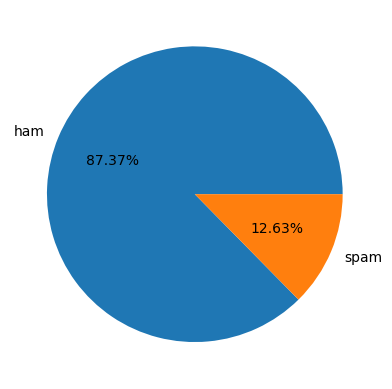

In [22]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f%%")
plt.savefig("Pie Chart.png", dpi=300, bbox_inches='tight')
plt.show()

In [23]:
# Data is imbalanced

In [24]:
import nltk

In [25]:
!pip install nltk

In [26]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ARKADIP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [27]:
# num of characters
df['num_characters'] = df['text'].apply(len)

In [28]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [29]:
# num of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [30]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [31]:
# num of sentences
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [32]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [33]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [34]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [35]:
# spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


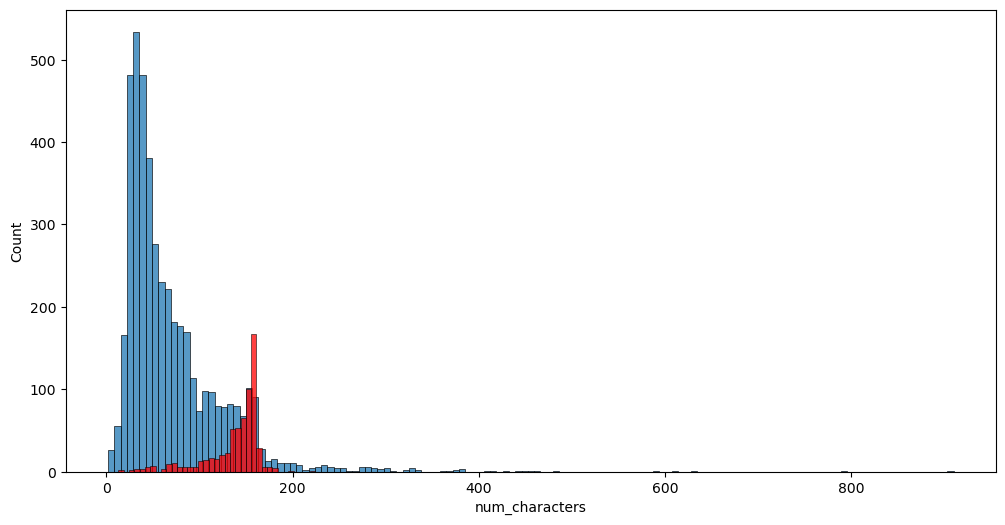

In [36]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']== 0]['num_characters'])
sns.histplot(df[df['target']== 1]['num_characters'],color='red')
plt.savefig("Spam vs Ham characters.png", dpi=300, bbox_inches='tight')

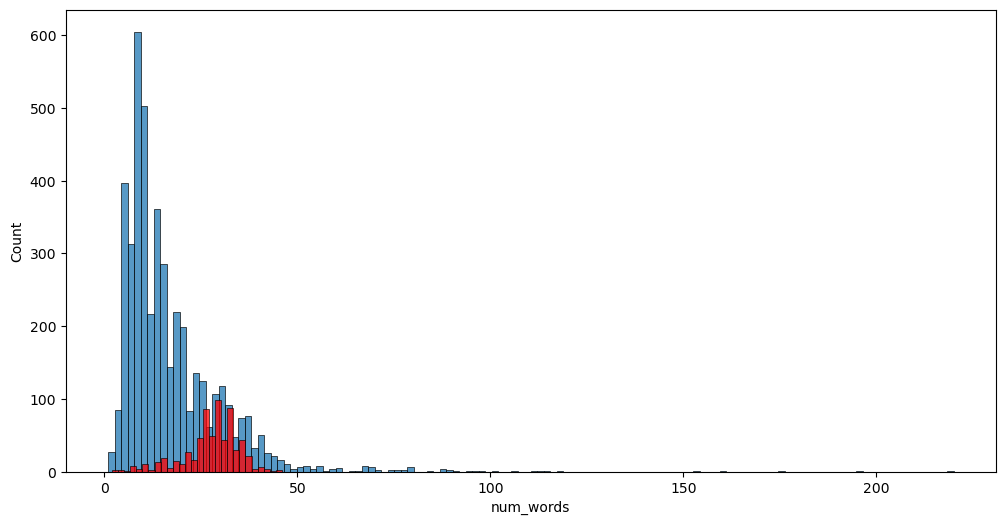

In [37]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']== 0]['num_words'])
sns.histplot(df[df['target']== 1]['num_words'],color='red')
plt.savefig("Spam vs Ham words.png", dpi=300, bbox_inches='tight')

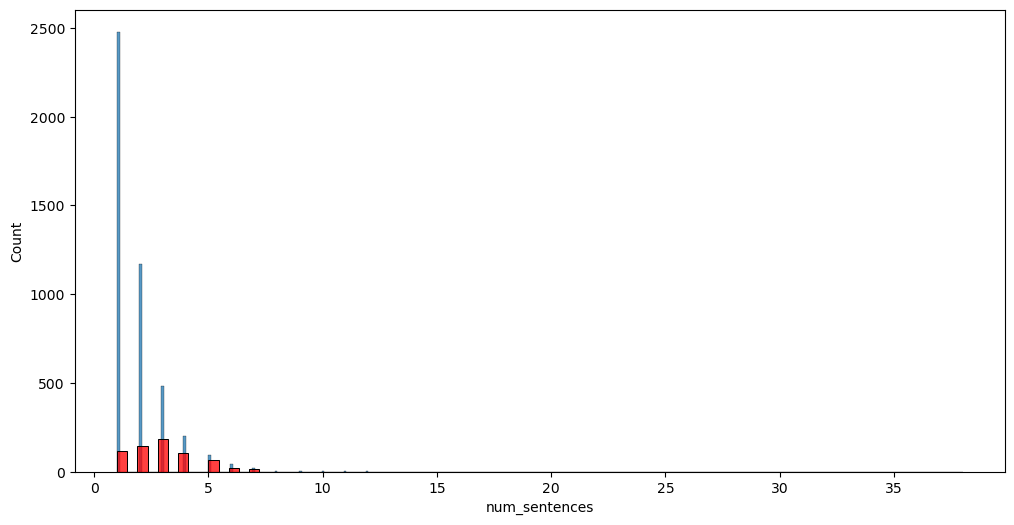

In [38]:
plt.figure(figsize=(12,6))
#plt.title("Histogram of the sentences of spam and ham email")
sns.histplot(df[df['target']== 0]['num_sentences'])
sns.histplot(df[df['target']== 1]['num_sentences'],color='red')
plt.savefig("Spam vs Ham sentences.png", dpi=300, bbox_inches='tight')

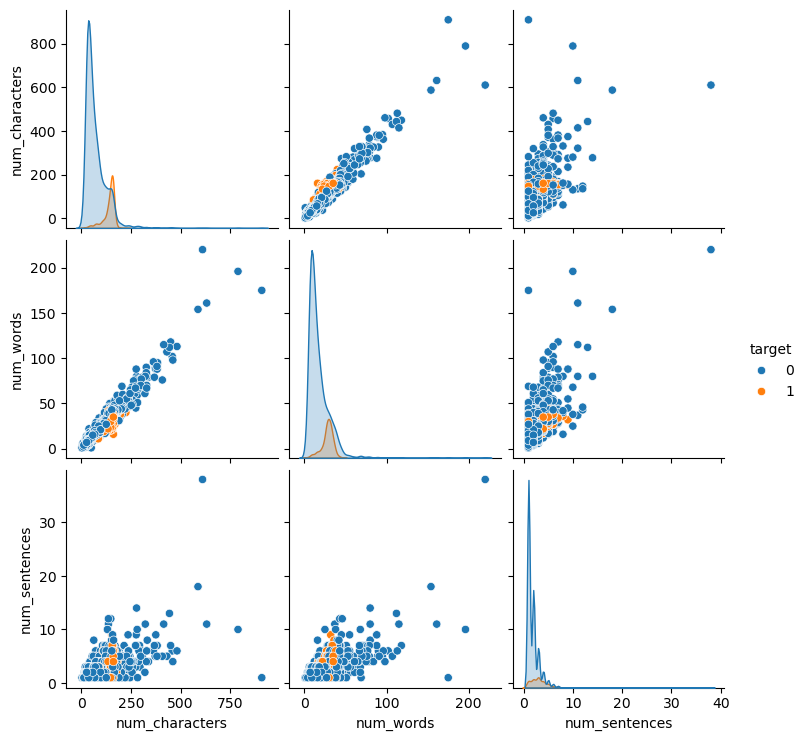

In [39]:
sns.pairplot(df,hue='target')

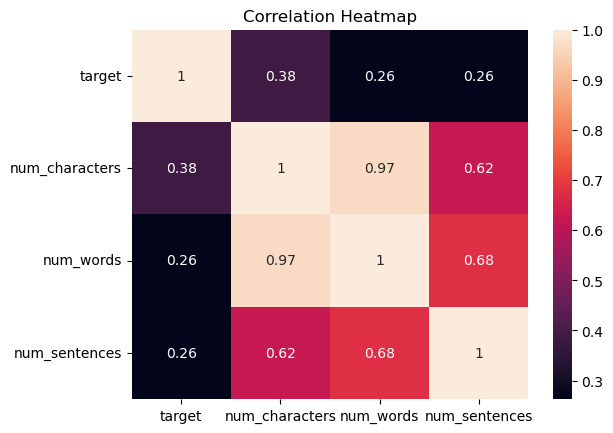

In [40]:
# Select only numerical columns for correlation
df_numerical = df[['target', 'num_characters', 'num_words', 'num_sentences']]
sns.heatmap(df_numerical.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.savefig("Correlation Heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# 3. Data Preprocessing
#  (a)Lower case
#  (b)Tokenization
#  (c)Removing special characters
#  (d)Removing stop words and punctuation
#  (e)Stemming

In [42]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [43]:
import string
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)        
    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [44]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords.words('English')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ARKADIP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [45]:
transform_text('Hello.How are you ? Efforts never die !')

'effort never die'

In [46]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [47]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('struggling')

'struggl'

In [48]:
df['transformed_text'] = df['text'].apply(transform_text)

In [49]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [50]:
!pip install wordcloud

In [51]:
from wordcloud import WordCloud
wc= WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [52]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

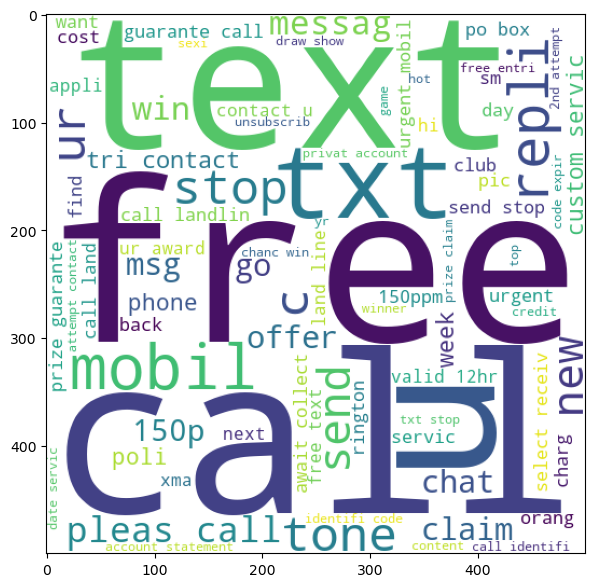

In [53]:
plt.figure(figsize=(15,7))
plt.imshow(spam_wc)

In [54]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

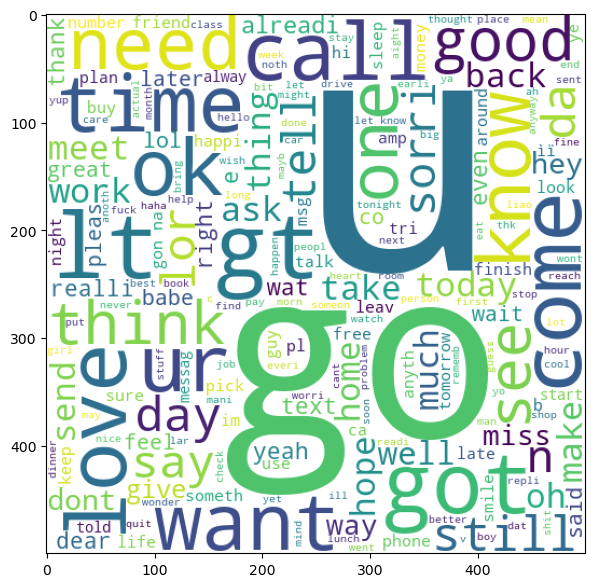

In [55]:
plt.figure(figsize=(15,7))
plt.imshow(ham_wc)

In [56]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [57]:
spam_corpus=[]
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [58]:
len(spam_corpus)

9939

In [59]:
spam_corpus

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

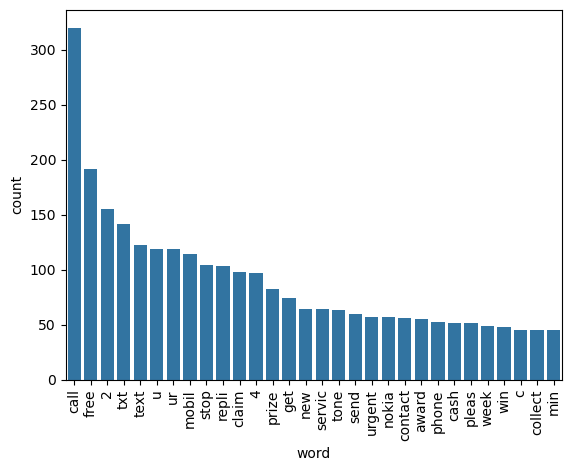

In [60]:
from collections import Counter
spam_common_words = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(data=spam_common_words, x='word', y='count')
# sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[0],pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.savefig("Spam_Words.png", dpi=300, bbox_inches='tight')
plt.show()

In [61]:
ham_corpus=[]
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [62]:
len(ham_corpus)

35404

In [63]:
ham_corpus

['go',
 'jurong',
 'point',
 'crazi',
 'avail',
 'bugi',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'got',
 'amor',
 'wat',
 'ok',
 'lar',
 'joke',
 'wif',
 'u',
 'oni',
 'u',
 'dun',
 'say',
 'earli',
 'hor',
 'u',
 'c',
 'alreadi',
 'say',
 'nah',
 'think',
 'goe',
 'usf',
 'live',
 'around',
 'though',
 'even',
 'brother',
 'like',
 'speak',
 'treat',
 'like',
 'aid',
 'patent',
 'per',
 'request',
 'mell',
 'oru',
 'minnaminungint',
 'nurungu',
 'vettam',
 'set',
 'callertun',
 'caller',
 'press',
 '9',
 'copi',
 'friend',
 'callertun',
 'gon',
 'na',
 'home',
 'soon',
 'want',
 'talk',
 'stuff',
 'anymor',
 'tonight',
 'k',
 'cri',
 'enough',
 'today',
 'search',
 'right',
 'word',
 'thank',
 'breather',
 'promis',
 'wont',
 'take',
 'help',
 'grant',
 'fulfil',
 'promis',
 'wonder',
 'bless',
 'time',
 'date',
 'sunday',
 'oh',
 'k',
 'watch',
 'eh',
 'u',
 'rememb',
 '2',
 'spell',
 'name',
 'ye',
 'v',
 'naughti',
 'make',
 'v',
 'wet',
 'fine',
 'thatåõ',
 'wa

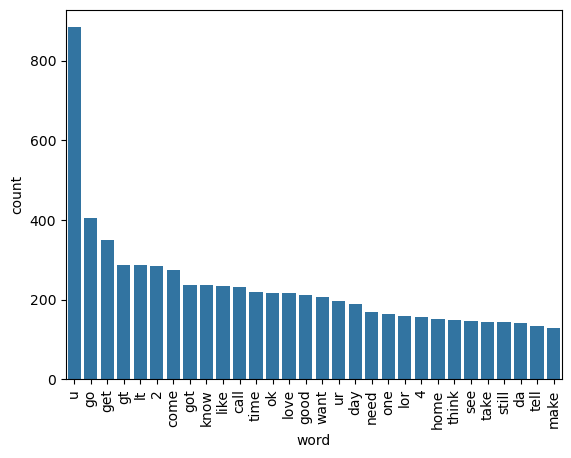

In [64]:
ham_common_words = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['word', 'count'])
sns.barplot(data=ham_common_words, x='word', y='count')
# sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[0],pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.savefig("Ham_Words.png", dpi=300, bbox_inches='tight')
plt.show()

# 4. Model Building

In [66]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=5000)

In [67]:
# x=cv.fit_transform(df['transformed_text']).toarray()

In [68]:
x=tfidf.fit_transform(df['transformed_text']).toarray()

In [69]:
# from sklearn.preprocessing import MinMaxScaler
# scaler=MinMaxScaler()
# x=scaler.fit_transform(x)

In [70]:
# Appending the num character col to x
#x=np.hstack((x,df['num_characters'].values.reshape(-1,1)))

In [71]:
x

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [72]:
x.shape

(5169, 5000)

In [73]:
y=df['target'].values

In [74]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [75]:
from sklearn.model_selection import train_test_split

In [76]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [77]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score

In [78]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [79]:
gnb.fit(x_train,y_train)
y_pred = gnb.predict(x_test)
y_pred_train = gnb.predict(x_train)
print("Train_Accuracy : ",accuracy_score(y_train,y_pred_train))
print("Test_Accuracy : ",accuracy_score(y_test,y_pred))
print("Precision : ",precision_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("F1_Score : ",f1_score(y_test,y_pred))
print("Confusion_Matrix : \n",confusion_matrix(y_test,y_pred))

Train_Accuracy :  0.9088270858524788
Test_Accuracy :  0.8762088974854932
Precision :  0.5231481481481481
Recall :  0.8188405797101449
F1_Score :  0.6384180790960452
Confusion_Matrix : 
 [[793 103]
 [ 25 113]]


In [80]:
mnb.fit(x_train,y_train)
y_pred = mnb.predict(x_test)
y_pred_train = mnb.predict(x_train)
print("Train_Accuracy : ",accuracy_score(y_train,y_pred_train))
print("Test_Accuracy : ",accuracy_score(y_test,y_pred))
print("Precision : ",precision_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("F1_Score : ",f1_score(y_test,y_pred))
print("Confusion_Matrix : \n",confusion_matrix(y_test,y_pred))

Train_Accuracy :  0.9731559854897219
Test_Accuracy :  0.9622823984526112
Precision :  1.0
Recall :  0.717391304347826
F1_Score :  0.8354430379746836
Confusion_Matrix : 
 [[896   0]
 [ 39  99]]


In [81]:
bnb.fit(x_train,y_train)
y_pred = bnb.predict(x_test)
y_pred_train = bnb.predict(x_train)
print("Train_Accuracy : ",accuracy_score(y_train,y_pred_train))
print("Test_Accuracy : ",accuracy_score(y_test,y_pred))
print("Precision : ",precision_score(y_test,y_pred))
print("Recall : ",recall_score(y_test,y_pred))
print("F1_Score : ",f1_score(y_test,y_pred))
print("Confusion_Matrix : \n",confusion_matrix(y_test,y_pred))

Train_Accuracy :  0.9806529625151149
Test_Accuracy :  0.9777562862669246
Precision :  0.9914529914529915
Recall :  0.8405797101449275
F1_Score :  0.9098039215686274
Confusion_Matrix : 
 [[895   1]
 [ 22 116]]


In [82]:
# tfidf --> MNB

In [83]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [85]:
svc = SVC(kernel='sigmoid',gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
bnb = BernoulliNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)

In [86]:
clfs = {
    'SVC' : svc,
    'KNN' : knc,
    'MNB' : mnb,
    'BNB' : bnb,
    'DT' : dtc,
    'LR' : lrc,
    'RF' : rfc,
    'GBDT' : gbdt,
    
}

In [87]:
def train_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train) # Training the model
    y_pred_train=clf.predict(x_train) 
    y_pred=clf.predict(x_test)
    Train_accuracy=accuracy_score(y_train,y_pred_train)
    Test_accuracy=accuracy_score(y_test,y_pred)
    Precision=precision_score(y_test,y_pred)
    Recall=recall_score(y_test,y_pred)
    F1_Score=f1_score(y_test,y_pred)
    Confusion_Matrix=confusion_matrix(y_test,y_pred) # for test dataset

    return Train_accuracy,Test_accuracy,Precision,Recall,F1_Score,Confusion_Matrix

In [88]:
train_classifier(svc,x_train,y_train,x_test,y_test)

(0.9845223700120919,
 0.9748549323017408,
 0.9745762711864406,
 0.8333333333333334,
 0.8984375,
 array([[893,   3],
        [ 23, 115]], dtype=int64))

In [89]:
Training_accuracy_scores = []
Testing_accuracy_scores = []
Precision_scores = []
Recall_scores = []
F1_Score = []
Confusion_Matrix_scores = []
for name,clf in clfs.items():
    current_train_accuracy,current_test_accuracy,current_precision,current_recall,current_f1_score,current_confusion_matrix = train_classifier(clf,x_train,y_train,x_test,y_test)
    print("For ",name ,":")
    print("Training_Accuracy - ",current_train_accuracy)
    print("Testing_Accuracy - ",current_test_accuracy)
    print("Precision - ",current_precision)
    print("Recall - ",current_recall)
    print("F1-Score - ",current_f1_score)
    print("Confusion_Matrix - \n ",current_confusion_matrix)
    Training_accuracy_scores.append(current_train_accuracy)
    Testing_accuracy_scores.append(current_test_accuracy)
    Precision_scores.append(current_precision)
    Recall_scores.append(current_recall)
    F1_Score.append(current_f1_score)
    Confusion_Matrix_scores.append(current_confusion_matrix)

For  SVC :
Training_Accuracy -  0.9845223700120919
Testing_Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
Recall -  0.8333333333333334
F1-Score -  0.8984375
Confusion_Matrix - 
  [[893   3]
 [ 23 115]]
For  KNN :
Training_Accuracy -  0.9201934703748489
Testing_Accuracy -  0.902321083172147
Precision -  1.0
Recall -  0.26811594202898553
F1-Score -  0.4228571428571429
Confusion_Matrix - 
  [[896   0]
 [101  37]]
For  MNB :
Training_Accuracy -  0.9731559854897219
Testing_Accuracy -  0.9622823984526112
Precision -  1.0
Recall -  0.717391304347826
F1-Score -  0.8354430379746836
Confusion_Matrix - 
  [[896   0]
 [ 39  99]]
For  BNB :
Training_Accuracy -  0.9806529625151149
Testing_Accuracy -  0.9777562862669246
Precision -  0.9914529914529915
Recall -  0.8405797101449275
F1-Score -  0.9098039215686274
Confusion_Matrix - 
  [[895   1]
 [ 22 116]]
For  DT :
Training_Accuracy -  0.9496977025392986
Testing_Accuracy -  0.9342359767891683
Precision -  0.8431372549019608
Recall -  0

In [90]:
performance_df=pd.DataFrame({'Algorithm':clfs.keys(),'Training Accuracy':Training_accuracy_scores,'Testing Accuracy':Testing_accuracy_scores,'Precision':Precision_scores,'Recall':Recall_scores,'F1-Score':F1_Score}).sort_values('Precision',ascending=True)

In [91]:
performance_df

,Algorithm,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
4,DT,0.949698,0.934236,0.843137,0.623188,0.716667
7,GBDT,0.967352,0.952611,0.908257,0.717391,0.801619
5,LR,0.961790,0.952611,0.949495,0.681159,0.793249
0,SVC,0.984522,0.974855,0.974576,0.833333,0.898438
6,RF,1.000000,0.970019,0.990826,0.782609,0.874494
3,BNB,0.980653,0.977756,0.991453,0.840580,0.909804
1,KNN,0.920193,0.902321,1.000000,0.268116,0.422857
2,MNB,0.973156,0.962282,1.000000,0.717391,0.835443


In [92]:
performance_df1=pd.melt(performance_df,id_vars="Algorithm")

In [93]:
performance_df1

,Algorithm,variable,value
0,DT,Training Accuracy,0.949698
1,GBDT,Training Accuracy,0.967352
2,LR,Training Accuracy,0.961790
3,SVC,Training Accuracy,0.984522
4,RF,Training Accuracy,1.000000
5,BNB,Training Accuracy,0.980653
6,KNN,Training Accuracy,0.920193
7,MNB,Training Accuracy,0.973156
8,DT,Testing Accuracy,0.934236
9,GBDT,Testing Accuracy,0.952611


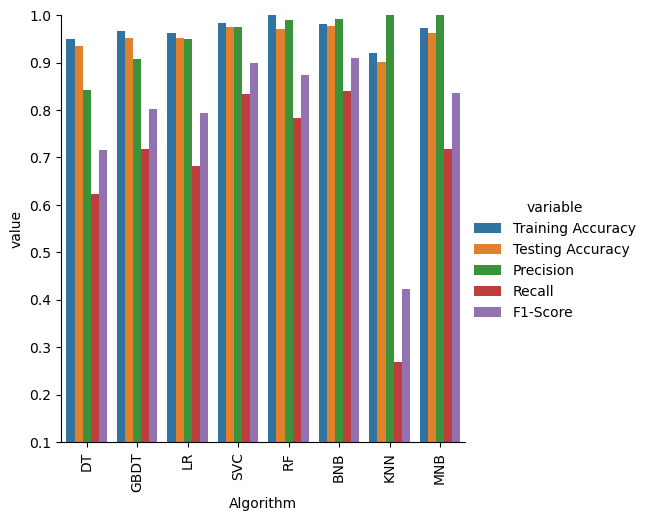

In [107]:
sns.catplot(x='Algorithm',y='value',hue='variable',data=performance_df1,kind='bar',height=5)
plt.ylim(0.1,1.0)
plt.xticks(rotation='vertical')
plt.savefig("Algorithm_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [109]:
# Model Improvement
# 1. Change the max_features parameter of TfIdf

In [111]:
temp_df=pd.DataFrame({'Algorithm':clfs.keys(),'Training_Accuracy_max_ft_3000':Training_accuracy_scores,'Testing_Accuracy_max_ft_3000':Testing_accuracy_scores,'Precision_max_ft_3000':Precision_scores,'Recall_max_ft_3000':Recall_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [113]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Training_Accuracy_scaling':Training_accuracy_scores,'Testing_Accuracy_scaling':Testing_accuracy_scores,'Precision_scaling':Precision_scores,'Recall_scaling':Recall_scores}).sort_values('Precision_scaling',ascending=False)

In [115]:
new_df=performance_df.merge(temp_df,on='Algorithm')

In [117]:
new_df_scaled=new_df.merge(temp_df,on='Algorithm')

In [119]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Training_Accuracy_num_chars':Training_accuracy_scores,'Testing_Accuracy_num_chars':Testing_accuracy_scores,'Precision_num_chars':Precision_scores,'Recall_num_chars':Recall_scores}).sort_values('Precision_num_chars',ascending=False)

In [121]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Training_Accuracy_scaling_x,Testing_Accuracy_scaling_x,Precision_scaling_x,Recall_scaling_x,Training_Accuracy_scaling_y,Testing_Accuracy_scaling_y,Precision_scaling_y,Recall_scaling_y,Training_Accuracy_num_chars,Testing_Accuracy_num_chars,Precision_num_chars,Recall_num_chars
0,DT,0.949698,0.934236,0.843137,0.623188,0.716667,0.949698,0.934236,0.843137,0.623188,0.949698,0.934236,0.843137,0.623188,0.949698,0.934236,0.843137,0.623188
1,GBDT,0.967352,0.952611,0.908257,0.717391,0.801619,0.967352,0.952611,0.908257,0.717391,0.967352,0.952611,0.908257,0.717391,0.967352,0.952611,0.908257,0.717391
2,LR,0.961790,0.952611,0.949495,0.681159,0.793249,0.961790,0.952611,0.949495,0.681159,0.961790,0.952611,0.949495,0.681159,0.961790,0.952611,0.949495,0.681159
3,SVC,0.984522,0.974855,0.974576,0.833333,0.898438,0.984522,0.974855,0.974576,0.833333,0.984522,0.974855,0.974576,0.833333,0.984522,0.974855,0.974576,0.833333
4,RF,1.000000,0.970019,0.990826,0.782609,0.874494,1.000000,0.970019,0.990826,0.782609,1.000000,0.970019,0.990826,0.782609,1.000000,0.970019,0.990826,0.782609
5,BNB,0.980653,0.977756,0.991453,0.840580,0.909804,0.980653,0.977756,0.991453,0.840580,0.980653,0.977756,0.991453,0.840580,0.980653,0.977756,0.991453,0.840580
6,KNN,0.920193,0.902321,1.000000,0.268116,0.422857,0.920193,0.902321,1.000000,0.268116,0.920193,0.902321,1.000000,0.268116,0.920193,0.902321,1.000000,0.268116
7,MNB,0.973156,0.962282,1.000000,0.717391,0.835443,0.973156,0.962282,1.000000,0.717391,0.973156,0.962282,1.000000,0.717391,0.973156,0.962282,1.000000,0.717391
